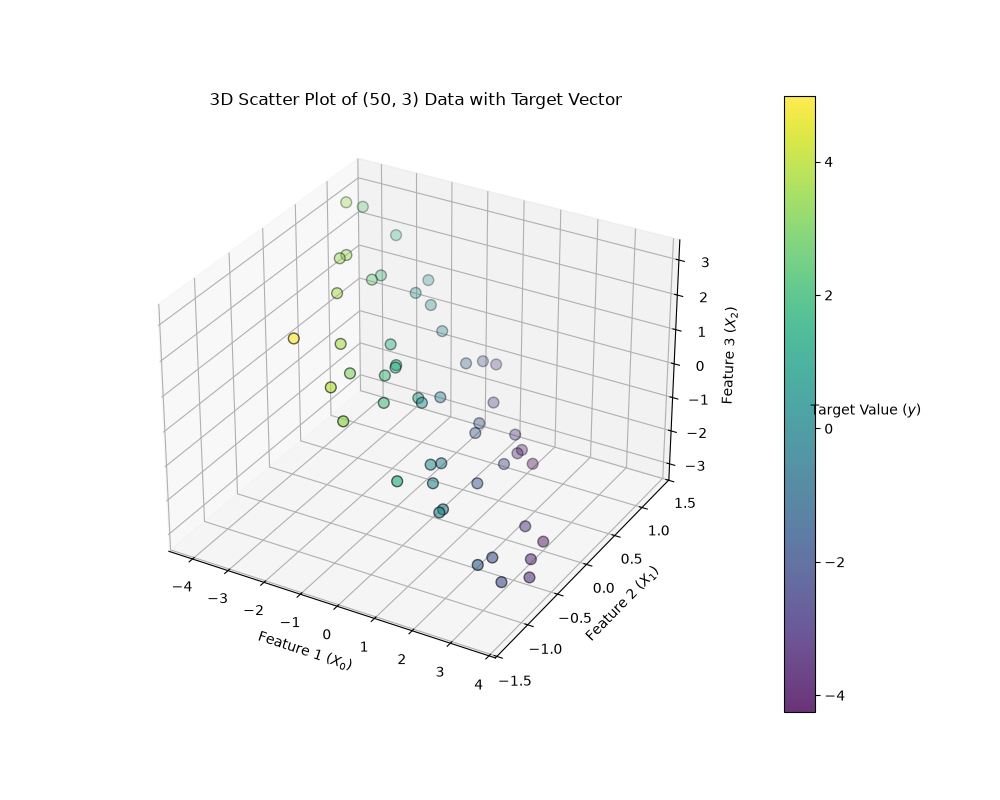

In [ ]:
#%matplotlib widget # After installing dependency remove that # at front to get interactive view of graph
import os
import sys

import matplotlib.pyplot as plt

parent_dir = os.path.abspath("..") # parent root path

if parent_dir not in sys.path:
  sys.path.append(parent_dir)

from tests.data_generator import * 

centered = True # toggle to see the differences

X,y = data_generator()

centered_dataset = []
if centered:
  for _ in X:
    centered_feature = _ - np.mean(_)
    centered_dataset.append(centered_feature)
  X = np.array(centered_dataset) # Making centered dataset

y_flat = y.ravel()
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], 
                     c=y_flat, 
                     cmap='viridis', 
                     s=60, 
                     edgecolor='k', 
                     alpha=0.8)

# 4. Labels and styling
ax.set_title("3D Scatter Plot of (50, 3) Data with Target Vector")
ax.set_xlabel("Feature 1 ($X_0$)")
ax.set_ylabel("Feature 2 ($X_1$)")
ax.set_zlabel("Feature 3 ($X_2$)")

# 5. Add a colorbar to show what the colors represent
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Value ($y$)', rotation=0, labelpad=15)

plt.show()

### Implementing PCA for reducing dimensional requirements for given dataset
1. Centering given dataset
2. Finding covariance matrix
3. Eigen vectors and eignen values
4. Making new projection

### Mathematical Insights
with first iteration complex number came inside the pipeline, broke the visualization, along with making more problems
we could have eigen vectors being computed complex due to dataset 
    Q : How to handle intermediate complex numbers into computing eigen vectors ?
**Plot Issues with complex number | How this originated ?**
With computing eigen values, precission up to 16th values makes introduction of complex number into picture which cascades to break the visualization pipeline to visualize the complex numbers

    Eigen values -> Projected values -> Visualization
**Fix**
Make simple use of real function to ignore that pricision into calculating eigen computation


#### Some critical observations with numpy indices to learn
+ Sorting arrays with respect to one another
+ Making slices and cuts with our requirements

```
pack[:,:k]
```
Means we are taking all rows as it is, but taking columns into range which fits up to 
possible exception out of range

**Indexing flips**
np.argsort(values) # returns just the index required for ascending sort | [::-1] directional flip
values[:, indexing]  # **targeting columns sort now row sort with respect to indexing**


Maping vector : [[-0.75572354  0.11016521  0.64555833]
 [ 0.30910937 -0.80903047  0.4999211 ]], with shape : (2, 3)
Original X : (50, 3)
Projected quantity : (2, 50) type check <class 'numpy.ndarray'>


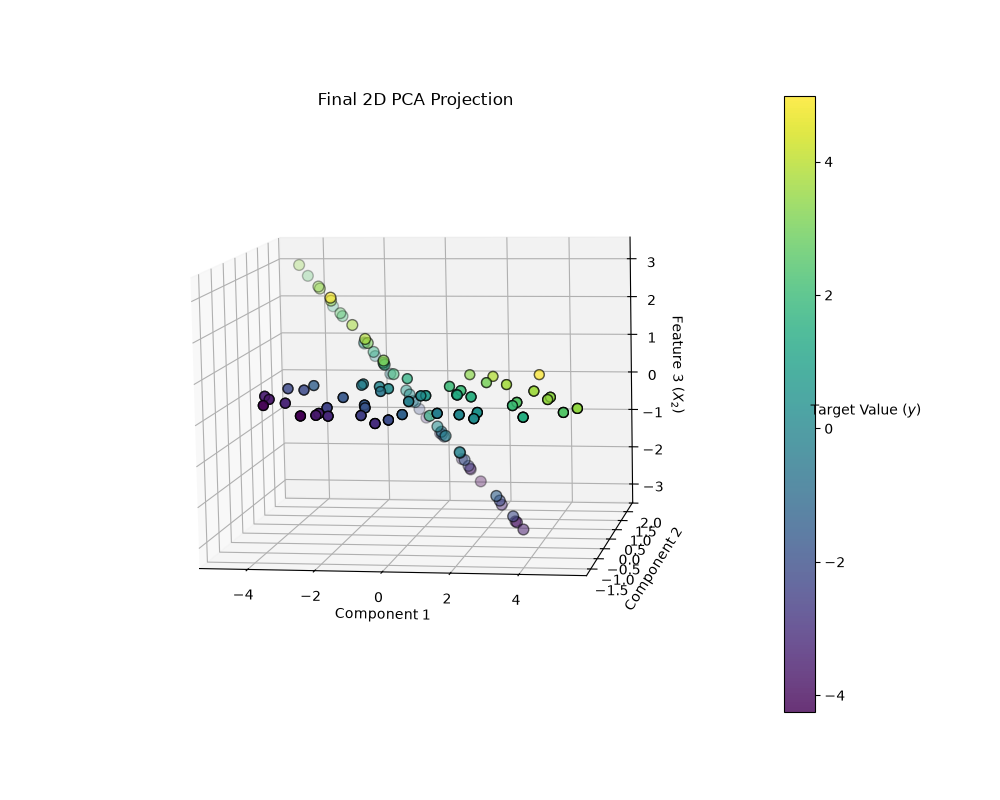

In [40]:
import numpy as np
import matplotlib.pyplot as plt
# Util function


# Mock function | for k pick
def k_sub_dimensional(target_matrix,k):
    '''
    input : target matrix
    output: transformation matrix for maping to lower dimension
    '''
    # with eig and eigh we can induece either complex to break our pipeline or eigh for real number flow :)
    eigen_values, eigen_vectors = np.linalg.eigh(target_matrix)
    indx = np.argsort(eigen_values)[::-1]

    eigen_vectors = eigen_vectors[:, indx]  # sorting columns of eigen vector matrix

    return eigen_vectors[:,: k].T 

covariance_matrix = X.T @ X  # shapes d x n n x d -> d x d

maping_vector = k_sub_dimensional(covariance_matrix, 2)
print(f"Maping vector : {maping_vector}, with shape : {maping_vector.shape}")

# We can now Project the original dataset into this new dimension

print(f"Original X : {X.shape}")
projected_dataset = maping_vector @ X.T  # All data points expressed into 2 dimension 
print(f"Projected quantity : {projected_dataset.shape} type check {type(projected_dataset)}")

component_1 = projected_dataset[0, :].real  # First new feature direction of X
component_2 = projected_dataset[1, :].real  # Second new feature direction of X

projected_X = np.column_stack((component_1, component_2))

plt.scatter(x=component_1, y=component_2, c=y.ravel(), cmap='viridis', edgecolor='k', s=50)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Final 2D PCA Projection")
plt.show()





Psudo Inverse Computed with : [[ 2.01301607e-02  2.00206825e-02  2.00542072e-02  1.99766975e-02
   2.01077960e-02  1.99501306e-02  2.00452010e-02  2.00513894e-02
   2.00247932e-02  2.00763402e-02  2.01038195e-02  2.01282794e-02
   1.99734021e-02  2.01248340e-02  2.01398497e-02  2.01183997e-02
   1.99558425e-02  1.99246059e-02  1.99119243e-02  2.00672802e-02
   2.00887053e-02  2.00552478e-02  2.00135362e-02  1.99557066e-02
   1.99549263e-02  2.01153615e-02  1.98912229e-02  1.99796081e-02
   1.99525662e-02  2.00923518e-02  1.99759186e-02  2.00326813e-02
   1.99312786e-02  2.00845950e-02  1.99823255e-02  2.00727146e-02
   1.98740946e-02  1.99168029e-02  1.99640809e-02  1.98759334e-02
   2.00205692e-02  1.99590325e-02  1.99630916e-02  1.98028794e-02
   1.99556558e-02  2.00235078e-02  1.98396863e-02  1.99930341e-02
   1.99027014e-02  1.98445483e-02]
 [-7.60573082e-04  1.09577179e-02  6.98175913e-03  1.39483695e-02
   7.03017878e-07  1.48286537e-02  5.41221420e-03  3.43642437e-03
   6.734655

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)